In [252]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False     # 解决保存图像是负号'-'显示为方块的问题

In [253]:
time = pd.read_csv("time.csv")
t_a = time.iloc[0:3, :]
t_b = time.iloc[3:6, :]
t_c = time.iloc[6:9, :]
t_a.head()

,t_900,t_800,t_700,t_600,t_500,t_400,t_300,t_200
0,4.05,7.10,10.07,13.10,16.10,19.12,22.27,25.38
1,3.54,6.73,9.76,12.62,15.82,18.77,21.87,24.92
2,3.79,6.82,9.76,12.85,15.73,18.71,21.60,24.70


In [254]:
delta_L = 3.487e-2  # 或者直接写 0.03487

# 2. 生成位移序列 s_i
# 如果你的实验是从第一个刻度开始计时的，s_i 表示相对于起点的距离
s_i = [i * delta_L for i in range(8)] 

# 3. 这里的 s_0 通常指第一个点对应的位置，如果从 0 开始，s_0 = 0
s_0 = s_i[0]

# 拟合 v_f

In [255]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimSun', 'Arial'] 
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = '14'

In [256]:
t_as = []
t_bs = []
t_cs = []
for i in range(3):
    t_as.append(t_a.iloc[i, :].to_numpy())
    t_bs.append(t_b.iloc[i, :].to_numpy())
    t_cs.append(t_c.iloc[i, :].to_numpy())
    
    
x_label = ["t_900", "t_800", "t_700", "t_600", "t_500", "t_400", "t_300", "t_200"]

In [257]:
from sklearn.linear_model import LinearRegression

In [258]:
t_cs[0]

array([2.04, 2.95, 3.98, 5.13, 6.21, 7.5 , 8.7 , 9.81])

In [259]:
v_f_as = []
v_f_a_legend = []

for i in range(3):
    linear_fit = LinearRegression()
    linear_fit.fit(
        X=np.array(t_as[i]).reshape((-1, 1)),
        y=s_i
        )
    v_f_as.append(linear_fit.coef_[0])
    v_f_a_legend.append(str("y = ") + str(np.round(linear_fit.coef_[0], 4)) + str("(x - ") + str(t_as[i][0]) + str(")") + "+ " + str(s_0))

v_f_as, v_f_a_legend

([0.011471846560796624, 0.011459092247579333, 0.011715703060449398],
 ['y = 0.0115(x - 4.05)+ 0.0',
  'y = 0.0115(x - 3.54)+ 0.0',
  'y = 0.0117(x - 3.79)+ 0.0'])

In [260]:
v_f_bs = []
v_f_b_legend = []

for i in range(3):
    linear_fit = LinearRegression()
    linear_fit.fit(
        X=np.array(t_bs[i]).reshape((-1, 1)),
        y=s_i
        )
    v_f_bs.append(linear_fit.coef_[0])
    v_f_b_legend.append(str("y = ") + str(np.round(linear_fit.coef_[0], 4)) + str("(x - ") + str(t_bs[i][0]) + str(")") + "+ " + str(s_0))

v_f_bs, v_f_b_legend

([0.02018990356575026, 0.019915790643214883, 0.01977548705631171],
 ['y = 0.0202(x - 2.95)+ 0.0',
  'y = 0.0199(x - 2.72)+ 0.0',
  'y = 0.0198(x - 3.59)+ 0.0'])

In [261]:
v_f_cs = []
v_f_c_legend = []

for i in range(3):
    linear_fit = LinearRegression()
    linear_fit.fit(
        X=np.array(t_cs[i]).reshape((-1, 1)),
        y=s_i
        )
    v_f_cs.append(linear_fit.coef_[0])
    v_f_c_legend.append(str("y = ") + str(np.round(linear_fit.coef_[0], 4)) + str("(x - ") + str(t_cs[i][0]) + str(")") + "+ " + str(s_0))

v_f_cs, v_f_c_legend

([0.03084798054091187, 0.030247152847466187, 0.030907664502697874],
 ['y = 0.0308(x - 2.04)+ 0.0',
  'y = 0.0302(x - 3.07)+ 0.0',
  'y = 0.0309(x - 3.85)+ 0.0'])

In [262]:
X_line = np.linspace(0, 8, 50)
y = v_f_as[0] * X_line + s_0

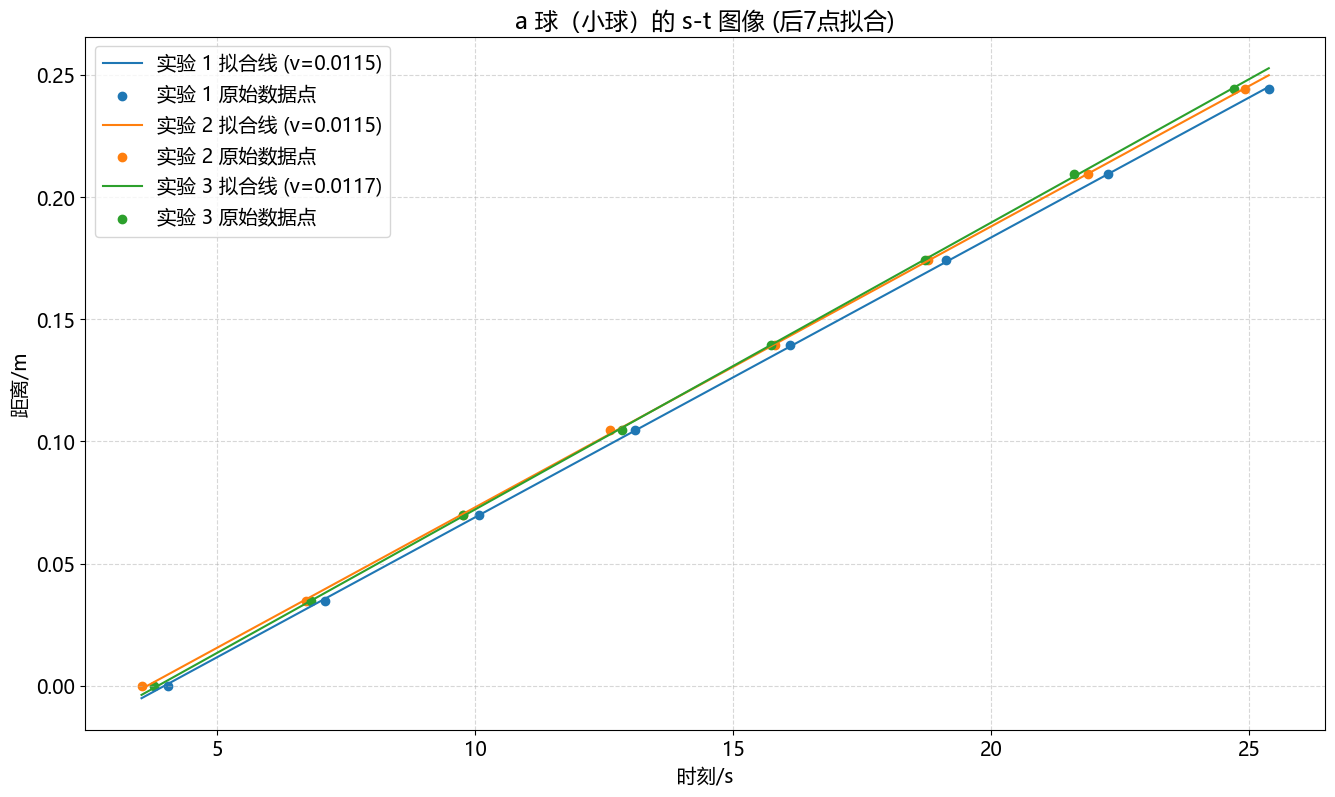

In [263]:
all_t = np.concatenate(t_as)
X_line = np.linspace(all_t.min(), all_t.max(), 100)

plt.figure(figsize=(16, 9))
plt.title("a 球（小球）的 s-t 图像 (后7点拟合)")

# 3. 循环进行拟合和绘图
for i in range(3):
    # 【关键修改】：t_as[i][1:] 表示取第2个到第8个点进行拟合
    # s_i 是 y 轴（位移），t_as[i] 是 x 轴（时间）
    # 注意：确保 s_i 也是一个包含 8 个元素的数组/列表
    v_fit, b_fit = np.polyfit(t_as[i][1:], s_i[1:], 1)
    
    # 绘制拟合线：使用后7点算出来的斜率和截距，但线条延伸到全范围
    plt.plot(X_line, v_fit * X_line + b_fit, label=f"实验 {i+1} 拟合线 (v={v_fit:.4f})")
    
    # 绘制所有散点：包含第1个点（索引为0的点）
    plt.scatter(t_as[i], s_i, label=f"实验 {i+1} 原始数据点")

# 4. 完善图表说明
plt.xlabel("时刻/s")
plt.ylabel("距离/m")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

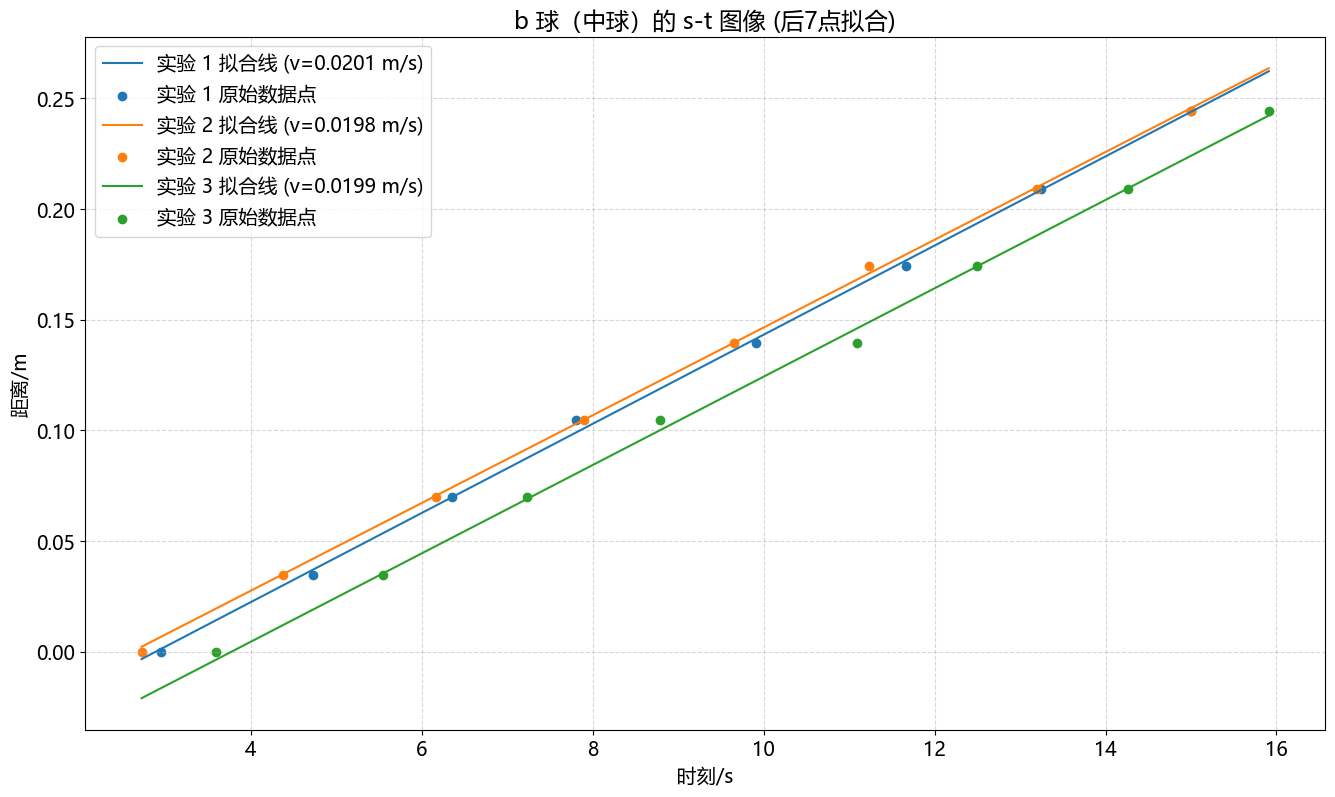

In [272]:
plt.figure(figsize=(16, 9))
plt.title("b 球（中球）的 s-t 图像 (后7点拟合)")

all_t_b = np.concatenate(t_bs)
X_line_b = np.linspace(all_t_b.min(), all_t_b.max(), 100)

for i in range(3):
    # 只用后7点拟合：s_i[1:] 和 t_bs[i][1:]
    v_fit, b_fit = np.polyfit(t_bs[i][1:], s_i[1:], 1)
    plt.plot(X_line_b, v_fit * X_line_b + b_fit, label=f"实验 {i+1} 拟合线 (v={v_fit:.4f} m/s)")
    plt.scatter(t_bs[i], s_i, label=f"实验 {i+1} 原始数据点")

plt.xlabel("时刻/s")
plt.ylabel("距离/m")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

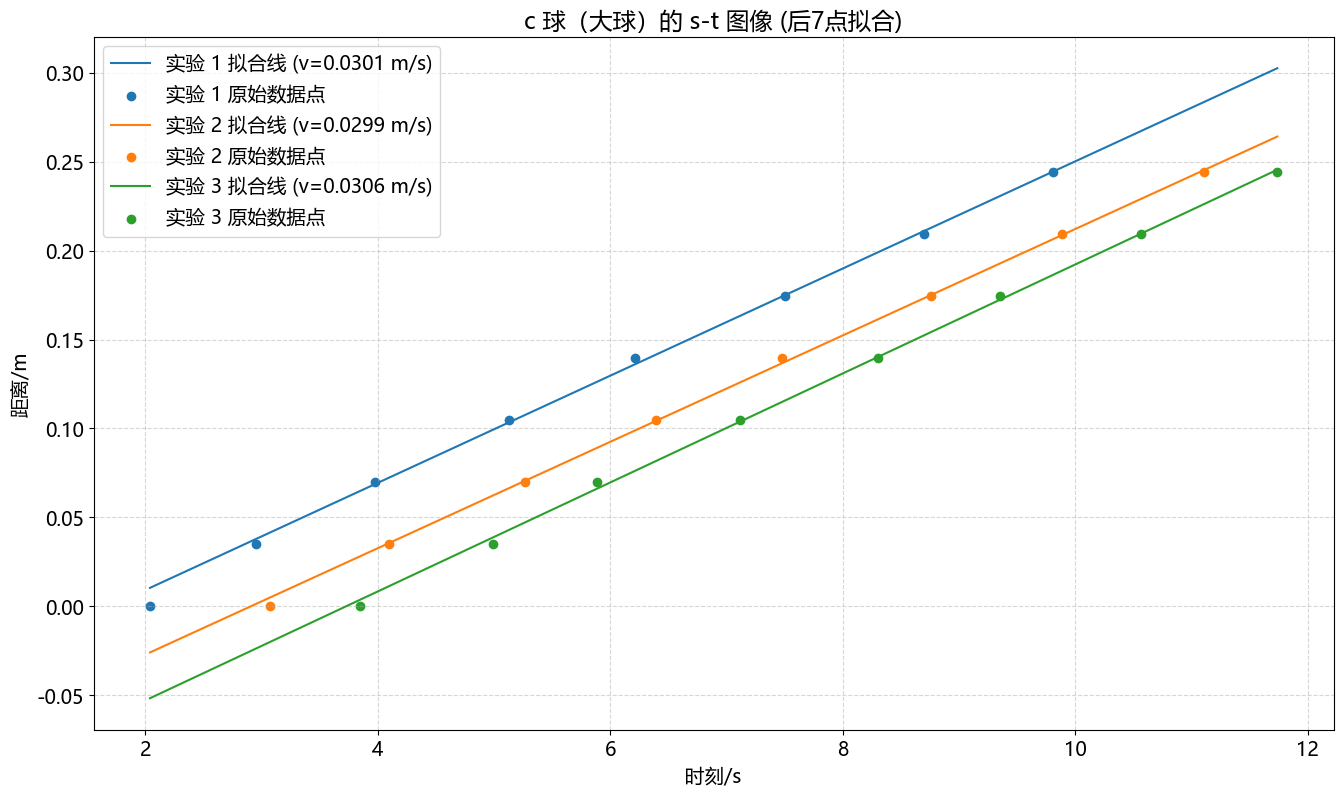

In [273]:
plt.figure(figsize=(16, 9))
plt.title("c 球（大球）的 s-t 图像 (后7点拟合)")

all_t_c = np.concatenate(t_cs)
X_line_c = np.linspace(all_t_c.min(), all_t_c.max(), 100)

for i in range(3):
    # 只用后7点拟合
    v_fit, b_fit = np.polyfit(t_cs[i][1:], s_i[1:], 1)
    plt.plot(X_line_c, v_fit * X_line_c + b_fit, label=f"实验 {i+1} 拟合线 (v={v_fit:.4f} m/s)")
    plt.scatter(t_cs[i], s_i, label=f"实验 {i+1} 原始数据点")

plt.xlabel("时刻/s")
plt.ylabel("距离/m")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [266]:
def eta(phi: float, rho: float, rho_0: float, 
        g: float, v_f: float, D: float, H: float):
    k1 = 1 + 2.4 * phi/D
    k2 = 1 + 1.7 * phi/H
    delta_rho = rho - rho_0
    return np.power(phi, 2)*g*delta_rho/(18 * v_f * k1 * k2)

In [267]:
g = 9.7887
phi_a = 1.548e-3
phi_b = 2.008e-3
phi_c = 2.496e-3
M_a = 0.37e-3
M_b = 1.01e-3
M_c = 1.74e-3
rho_a = M_a/(5 * np.pi * np.power(phi_a, 3))
rho_b = M_b/(5 * np.pi * np.power(phi_b, 3))
rho_c = M_c/(5 * np.pi * np.power(phi_c, 3))

rho = rho_c
rho_0 = 0.96e3
D = np.mean([63.40, 63.34, 63.64]) * 1e-3
H = np.mean([33.80, 33.90]) * 1e-2
D, H, rho_a, rho_b, rho_c, rho_0

(0.06346,
 0.33849999999999997,
 6349.930588196401,
 7941.643200594788,
 7123.536078683989,
 960.0)

In [268]:
v_f_a = np.mean([0.0114, 0.0111, 0.0112])
v_f_b = np.mean([0.0204, 0.0213, 0.0210])
v_f_c = np.mean([0.0312, 0.0312, 0.0324])
v_f_a, v_f_b, v_f_c

(0.011233333333333333, 0.020900000000000002, 0.031599999999999996)

In [269]:
eta_a = eta(phi_a, rho, rho_0, g, v_f_a, D, H)
eta_b = eta(phi_b, rho, rho_0, g, v_f_b, D, H)
eta_c = eta(phi_c, rho, rho_0, g, v_f_c, D, H)
eta_a, eta_b, eta_c

(0.6702603732045651, 0.5950007702482996, 0.5963478771861246)

In [270]:
def Re(v, rho, phi, eta):
    return v * rho * phi / eta

In [271]:
Re(v_f_a, rho_0, phi_a, eta_a), Re(v_f_b, rho_0, phi_b, eta_b), Re(v_f_c, rho_0, phi_c, eta_c)

(0.024906189694889003, 0.06771169721879051, 0.12697061379220376)